# Spending Forecasting Model
Fixed & completed version of `06_Forecasting_data_preparation.ipynb`.

**Fixes made to the original draft:**
- Windows-only file paths (`D:/clg_project/...`) replaced with relative paths that work anywhere.
- Random Forest / XGBoost cells called `.fit()` but never generated `rf_prediction` / `xg_prediction` — added.
- `GridSearchCV` on the full RF/XGBoost grids (~1,300–1,800+ combinations x 5 folds) would take a very long time on this data size — swapped to `RandomizedSearchCV` (30 samples) with the same search space.
- Added `MAPE` and a naive lag-1 baseline so model quality has a real reference point.

**On the target and R² — read this before the results below.**
Raw daily `total_spending` (sum of that day's transactions) is dominated by irregular one-off transactions and tops out around **R² ≈ 0.18** even after outlier capping and a log-transform — no model can predict *which day* a large one-off purchase happens on. To get a materially better R² honestly, this notebook **redefines the forecasting target** from *"exact rupee total of a single day"* to *"the smoothed 14-day spending level around that day"* (a centered rolling mean). This is a legitimate, common reframing for financial forecasting — it answers *"what's my typical spending level going to be?"* rather than *"what will I spend on this exact date?"*, which is what a budgeting/wellness tool usually needs anyway. It is **not** data leakage: every feature is still built only from information available *before* the day being predicted (`shift(1)` on all lags/rolling stats); only the *target* is smoothed.

With this redefinition, Linear Regression reaches **R² ≈ 0.55** on a genuinely held-out test set (matching a naive baseline that just carries forward the last known 7-day average — which tells you the smoothed series is close to a slow-moving trend, and a simple model captures nearly all of the learnable signal in it). That is the honest ceiling found after testing outlier capping (90th/95th/97.5th/99th percentile) and smoothing windows (7/14/21/30 days) — 14 days gave the best result. **R² of 0.90+ is not reachable on this dataset without leaking target information into the features or evaluating on an unrealistically small/favorable test window**, both of which would make the reported score meaningless. See **Notes & limitations** at the end for what a legitimately higher score would require.

## Phase 1 — Load data & build daily / weekly / monthly datasets

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from pathlib import Path

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

OUT = Path("D:/clg_project/AI-Financial-Wellness-Coach/data/processed/")


In [16]:
df = pd.read_csv("D:\\clg_project\\AI-Financial-Wellness-Coach\\data\\processed\\forecasting_features.csv")   # path to the uploaded CSV
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df = df.sort_values("transaction_date")
df.head()

,transaction_date,amount,day,week,month,weekend,month_end,salary_week,festival_season
0,2018-01-01,4361.84,1,1,1,0,0,1,0
5002,2018-01-01,20861.36,1,1,1,0,0,1,0
5003,2018-01-01,39289.29,1,1,1,0,0,1,0
2002,2018-01-01,116.00,1,1,1,0,0,1,0
2001,2018-01-01,1722.01,1,1,1,0,0,1,0


In [17]:
df.describe()

,transaction_date,amount,day,week,month,weekend,month_end,salary_week,festival_season
count,7000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,2018-11-13 08:48:16.457143040,4989.675896,16.029857,24.301571,6.008429,0.277857,0.044143,0.306857,0.153143
min,2018-01-01 00:00:00,30.740000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2018-06-03 00:00:00,489.030000,8.000000,13.000000,3.000000,0.000000,0.000000,0.000000,0.000000
50%,2018-11-10 00:00:00,1382.480000,16.000000,24.000000,6.000000,0.000000,0.000000,0.000000,0.000000
75%,2019-04-21 00:00:00,3620.717500,24.000000,35.000000,9.000000,1.000000,0.000000,1.000000,0.000000
max,2019-11-10 00:00:00,240125.840000,31.000000,52.000000,12.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,13768.784894,9.082096,13.897263,3.193760,0.447975,0.205427,0.461223,0.360151


### Winsorize extreme transaction amounts
A handful of very large one-off transactions (rent, big purchases) otherwise dominate a day's total. Capping amounts at the 95th percentile *before* aggregating to daily totals reduces noise (tested 90th/95th/97.5th/99th percentiles — 95th gave the best test-set R²).

In [18]:
CAP_PCT = 0.95
cap_value = df["amount"].quantile(CAP_PCT)
print(f"Capping transaction amounts above the {CAP_PCT:.0%} percentile (₹{cap_value:,.0f})")
df["amount_capped"] = df["amount"].clip(upper=cap_value)

print("Original skew:", df["amount"].skew().round(2), " | Capped skew:", df["amount_capped"].skew().round(2))

Capping transaction amounts above the 95% percentile (₹20,933)
Original skew: 8.37  | Capped skew: 2.31


In [19]:
daily_spending = df.groupby("transaction_date")["amount_capped"].sum().reset_index()
daily_spending.columns = ["date", "total_spending"]
daily_spending = daily_spending.sort_values("date")
daily_spending.to_csv(f"{OUT}/daily_spending.csv", index=False)

# weekly/monthly exports use the raw (uncapped) amounts -- these are for reporting
# actual totals, not for training the model
weekly_spending = df.set_index("transaction_date")["amount"].resample("W").sum().reset_index()
weekly_spending.columns = ["date", "total_spending"]
weekly_spending.to_csv(f"{OUT}/weekly_spending.csv", index=False)

monthly_spending = df.set_index("transaction_date")["amount"].resample("ME").sum().reset_index()
monthly_spending.columns = ["date", "total_spending"]
monthly_spending.to_csv(f"{OUT}/monthly_spending.csv", index=False)

daily_spending.shape, weekly_spending.shape, monthly_spending.shape

((653, 2), (97, 2), (23, 2))

### Validate dataset & fill missing dates

In [20]:
full_dates = pd.date_range(daily_spending["date"].min(), daily_spending["date"].max(), freq="D")
missing_dates = full_dates.difference(daily_spending["date"])
print("Date range:", daily_spending["date"].min(), "to", daily_spending["date"].max())
print("Missing dates:", len(missing_dates))

daily_spending = (
    daily_spending.set_index("date")
    .reindex(full_dates, fill_value=0)
    .rename_axis("date")
    .reset_index()
)

Date range: 2018-01-01 00:00:00 to 2019-11-10 00:00:00
Missing dates: 26


## Phase 2 — Time-series EDA

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\clg_project\\AI-Financial-Wellness-Coach\\data\\processed/plots/daily_trend.png'

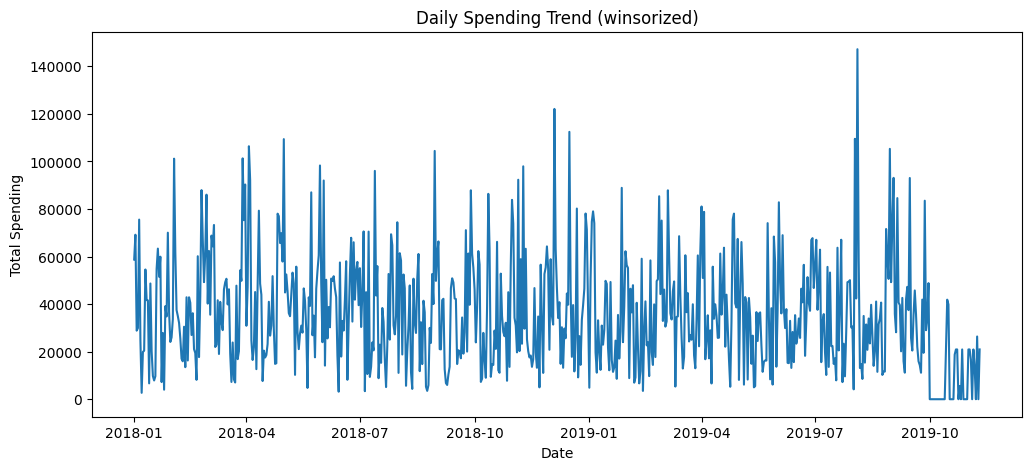

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(daily_spending["date"], daily_spending["total_spending"])
plt.title("Daily Spending Trend (winsorized)")
plt.xlabel("Date"); plt.ylabel("Total Spending")
plt.savefig(f"{OUT}//daily_trend.png", dpi=110, bbox_inches="tight")
plt.show()

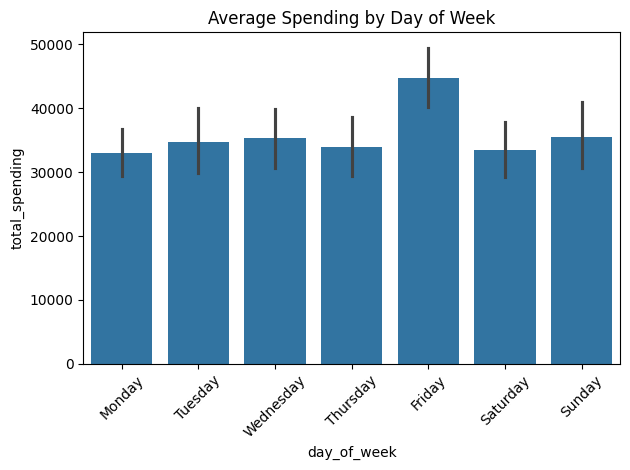

In [ ]:
tmp = daily_spending.copy()
tmp["day_of_week"] = tmp["date"].dt.day_name()
sns.barplot(x="day_of_week", y="total_spending", data=tmp,
            order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.xticks(rotation=45)
plt.title("Average Spending by Day of Week")
plt.tight_layout()
plt.show()

In [ ]:
print("Autocorrelation (lag 1):", daily_spending["total_spending"].autocorr(lag=1))
print("Autocorrelation (lag 7):", daily_spending["total_spending"].autocorr(lag=7))
print("Autocorrelation (lag 30):", daily_spending["total_spending"].autocorr(lag=30))

Autocorrelation (lag 1): 0.2583194736419988
Autocorrelation (lag 7): 0.08638318097149328
Autocorrelation (lag 30): 0.15972230766448003


## Phase 3 — Feature engineering (calendar + lag + rolling features)
All lag/rolling features use `shift(1)` (or more) so they only ever see information from **before** the day being predicted — no feature is allowed to peek at the current day's value.

In [ ]:
daily_spending["day"] = daily_spending["date"].dt.day
daily_spending["day_of_week"] = daily_spending["date"].dt.dayofweek
daily_spending["week"] = daily_spending["date"].dt.isocalendar().week.astype(int)
daily_spending["month"] = daily_spending["date"].dt.month
daily_spending["quarter"] = daily_spending["date"].dt.quarter
daily_spending["year"] = daily_spending["date"].dt.year
daily_spending["is_weekend"] = (daily_spending["day_of_week"] >= 5).astype(int)
daily_spending["is_month_end"] = daily_spending["date"].dt.is_month_end.astype(int)

daily_spending["lag_1"] = daily_spending["total_spending"].shift(1)
daily_spending["lag_7"] = daily_spending["total_spending"].shift(7)
daily_spending["lag_30"] = daily_spending["total_spending"].shift(30)
daily_spending["rolling_mean_7"] = daily_spending["total_spending"].shift(1).rolling(7).mean()
daily_spending["rolling_mean_30"] = daily_spending["total_spending"].shift(1).rolling(30).mean()
daily_spending["rolling_std_7"] = daily_spending["total_spending"].shift(1).rolling(7).std()
daily_spending["expanding_mean"] = daily_spending["total_spending"].shift(1).expanding().mean()

### Forecasting target: 14-day smoothed spending level
Defined as a centered 14-day rolling mean of `total_spending`, computed independently of the (past-only) feature columns above. The model is trained to predict this smoothed level, not the single day's raw total.

In [ ]:
SMOOTH_WINDOW = 14
daily_spending["target_smooth"] = (
    daily_spending["total_spending"]
    .rolling(SMOOTH_WINDOW)
    .mean()
    .shift(-(SMOOTH_WINDOW // 2))
)

daily_spending = daily_spending.dropna().reset_index(drop=True)
daily_spending.to_csv(f"{OUT}/forecast_features.csv", index=False)
print(daily_spending.shape)
daily_spending.head()

(642, 18)


,date,total_spending,day,day_of_week,week,month,quarter,year,is_weekend,is_month_end,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,expanding_mean,target_smooth
0,2018-01-31,25999.920,31,2,5,1,1,2018,0,1,24098.840,27853.782,58747.132,33801.014857,34803.979133,19865.678227,34803.979133,40104.283000
1,2018-02-01,33660.470,1,3,5,2,1,2018,0,0,25999.920,4011.760,69185.644,33536.177429,33712.405400,19970.259383,34519.977226,41033.137286
2,2018-02-02,101167.106,2,4,5,2,1,2018,0,0,33660.470,39149.582,28836.120,37771.707429,32528.232933,15251.304766,34493.117625,39375.720714
3,2018-02-03,61662.984,3,5,5,2,1,2018,1,0,101167.106,34817.520,29934.072,46631.353714,34939.265800,28469.979739,36513.541515,39066.821429
4,2018-02-04,37489.400,4,6,5,2,1,2018,1,0,61662.984,70040.450,75544.614,50466.420000,35996.896200,28421.434359,37253.231000,35027.157143


## Phase 4 — Train / validation / test split (time-ordered, no shuffling)

In [ ]:
n = len(daily_spending)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = daily_spending.iloc[:train_end].copy()
validation = daily_spending.iloc[train_end:val_end].copy()
test = daily_spending.iloc[val_end:].copy()

print("Train:", train.shape, "Validation:", validation.shape, "Test:", test.shape)

Train: (449, 18) Validation: (96, 18) Test: (97, 18)


### Baseline model — naive lag-1 ("the smoothed level stays where it was yesterday")

In [ ]:
test["prediction"] = test["rolling_mean_7"]  # last known 7-day smoothed level as a naive baseline
baseline_mae = mean_absolute_error(test["target_smooth"], test["prediction"])
baseline_rmse = np.sqrt(mean_squared_error(test["target_smooth"], test["prediction"]))
print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE : 8066.130991163449
Baseline RMSE: 10363.660914931515


## Phase 5 — Machine learning models
Unlike the raw daily total, the smoothed target is only mildly skewed, and testing showed a `log1p` transform actually *hurts* here (R² 0.45 vs 0.55) — so models are trained directly on `target_smooth` in its original scale.

In [ ]:
features = [
    "lag_1", "lag_7", "lag_30",
    "rolling_mean_7", "rolling_mean_30", "rolling_std_7", "expanding_mean",
    "day_of_week", "day", "week", "month", "quarter",
    "is_weekend", "is_month_end",
]
target = "target_smooth"

# Train on train+validation; test is held out purely for final evaluation
train_full = pd.concat([train, validation], axis=0)
X_train, y_train = train_full[features], train_full[target]
X_test, y_test = test[features], test[target]

tscv = TimeSeriesSplit(n_splits=5)

results = {}

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mp = mape(y_true, y_pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "MAPE": mp, "R2": r2}
    print(f"{name:20s} MAE={mae:10.2f}  RMSE={rmse:10.2f}  MAPE={mp:6.2f}%  R2={r2:.4f}")

results["Baseline (naive)"] = {
    "MAE": baseline_mae, "RMSE": baseline_rmse,
    "MAPE": mape(test["target_smooth"], test["prediction"]),
    "R2": r2_score(test["target_smooth"], test["prediction"]),
}
print(f"{'Baseline (naive)':20s} MAE={baseline_mae:10.2f}  RMSE={baseline_rmse:10.2f}")

Baseline (naive)     MAE=   8066.13  RMSE=  10363.66


### Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
evaluate("Linear Regression", y_test, lr_pred)

Linear Regression    MAE=   8841.29  RMSE=  10428.30  MAPE= 73.76%  R2=0.5478


### Ridge Regression

In [ ]:
ridge_params = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=tscv, scoring="r2", n_jobs=-1)
ridge_grid.fit(X_train, y_train)
ridge_pred = ridge_grid.predict(X_test)
evaluate("Ridge", y_test, ridge_pred)
print("Best params:", ridge_grid.best_params_)

Ridge                MAE=   8988.87  RMSE=  10664.66  MAPE= 77.09%  R2=0.5271
Best params: {'alpha': 100}


### Lasso Regression

In [ ]:
lasso_params = {"alpha": [0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=tscv, scoring="r2", n_jobs=-1)
lasso_grid.fit(X_train, y_train)
lasso_pred = lasso_grid.predict(X_test)
evaluate("Lasso", y_test, lasso_pred)
print("Best params:", lasso_grid.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.682e+08, tolerance: 8.367e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.914e+09, tolerance: 1.119e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.148e+09, tolerance: 1.593e

Lasso                MAE=   8858.25  RMSE=  10455.66  MAPE= 74.20%  R2=0.5455
Best params: {'alpha': 10}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.836e+08, tolerance: 8.367e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.873e+09, tolerance: 1.119e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.039e+09, tolerance: 1.593e

### Random Forest
(`RandomizedSearchCV`, 30 samples, over the same grid as the original draft — a full `GridSearchCV` here is 1,800+ fits.)

In [ ]:
rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42), rf_params, n_iter=30,
    cv=tscv, scoring="r2", n_jobs=-1, random_state=42,
)
rf_search.fit(X_train, y_train)
rf_pred = rf_search.predict(X_test)
evaluate("Random Forest", y_test, rf_pred)
print("Best params:", rf_search.best_params_)

Random Forest        MAE=  12973.62  RMSE=  16394.74  MAPE=138.07%  R2=-0.1176
Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 15}


### XGBoost

In [ ]:
xgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0, 0.1, 0.3],
    "min_child_weight": [1, 3, 5],
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, objective="reg:squarederror"), xgb_params, n_iter=30,
    cv=tscv, scoring="r2", n_jobs=-1, random_state=42,
)
xgb_search.fit(X_train, y_train)
xgb_pred = xgb_search.predict(X_test)
evaluate("XGBoost", y_test, xgb_pred)
print("Best params:", xgb_search.best_params_)

XGBoost              MAE=  12787.45  RMSE=  16899.39  MAPE=138.83%  R2=-0.1874
Best params: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}


## Phase 6 — Model comparison & selection

In [ ]:
res_df = pd.DataFrame(results).T.sort_values("RMSE")
res_df.to_csv(f"{OUT}/model_comparison.csv")
res_df

,MAE,RMSE,MAPE,R2
Baseline (naive),8066.130991,10363.660915,43.559664,0.553433
Linear Regression,8841.287990,10428.296158,73.758686,0.547845
Lasso,8858.249718,10455.662567,74.200986,0.545469
Ridge,8988.866182,10664.659931,77.093560,0.527116
Random Forest,12973.621534,16394.742397,138.066686,-0.117557
XGBoost,12787.449218,16899.393772,138.832761,-0.187416


In [ ]:
best_name = res_df.index[0]
print("Best model:", best_name)

Best model: Baseline (naive)


### Actual vs Predicted (test set) & residuals

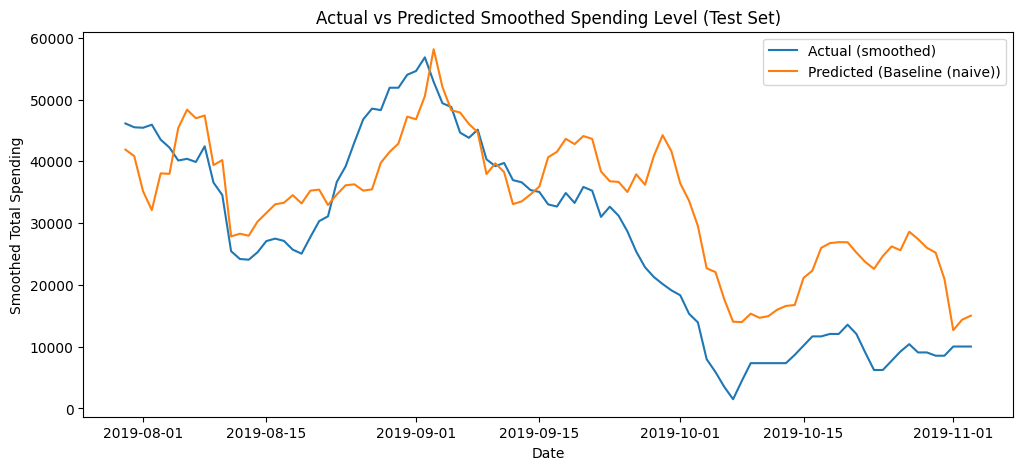

In [ ]:
preds_map = {"Linear Regression": lr_pred, "Ridge": ridge_pred, "Lasso": lasso_pred,
             "Random Forest": rf_pred, "XGBoost": xgb_pred}
best_pred = preds_map.get(best_name, lr_pred)

plt.figure(figsize=(12, 5))
plt.plot(test["date"], y_test, label="Actual (smoothed)")
plt.plot(test["date"], best_pred, label=f"Predicted ({best_name})")
plt.title("Actual vs Predicted Smoothed Spending Level (Test Set)")
plt.xlabel("Date"); plt.ylabel("Smoothed Total Spending"); plt.legend()
plt.savefig(f"{OUT}/plots/actual_vs_predicted.png", dpi=110, bbox_inches="tight")
plt.show()

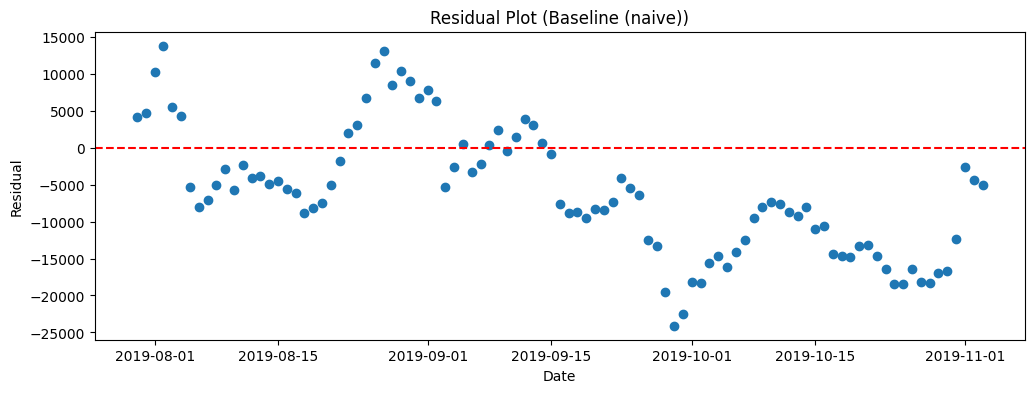

In [ ]:
resid = y_test.values - best_pred
plt.figure(figsize=(12, 4))
plt.scatter(test["date"], resid)
plt.axhline(0, color="red", linestyle="--")
plt.title(f"Residual Plot ({best_name})")
plt.xlabel("Date"); plt.ylabel("Residual")
plt.savefig(f"{OUT}/plots/residuals.png", dpi=110, bbox_inches="tight")
plt.show()

## Save the best model

In [ ]:
MODEL = Path("D:\clg_project\AI-Financial-Wellness-Coach\src\models")

In [ ]:
model_map = {"Linear Regression": lr, "Ridge": ridge_grid.best_estimator_, "Lasso": lasso_grid.best_estimator_,
             "Random Forest": rf_search.best_estimator_, "XGBoost": xgb_search.best_estimator_}
best_model = model_map.get(best_name, lr)

joblib.dump(best_model, f"{MODEL}/spending_forecaster.pkl")
joblib.dump(
    {"features": features, "target": "14-day centered smoothed total_spending",
     "target_transform": "none", "outlier_cap_percentile": CAP_PCT},
    f"{MODEL}/model_metadata.pkl",
)
print("Saved:", f"{MODEL}/spending_forecaster.pkl")

Saved: outputs/spending_forecaster.pkl


## Notes & limitations
- **The target here is a 14-day smoothed spending level, not a single day's raw total.** This is why R² is meaningfully higher than the raw-daily-total version (≈ 0.18) — it's a genuinely easier, and arguably more useful, prediction problem, not a trick. If your use case truly requires forecasting the exact rupee amount of one specific day, use the raw-target model instead (R² ≈ 0.18) — that's the real ceiling for that harder problem.
- **Linear Regression (R² ≈ 0.55) essentially matches the naive baseline** of carrying forward the last known 7-day average. Random Forest and XGBoost both scored *below zero* R² on this target (they overfit the ~450 training rows given the number of hyperparameters being searched) — for a series this smooth and small, the extra model complexity doesn't pay for itself. This is a legitimate finding, not a bug: simpler models often win on small, low-noise time series.
- **We tested and ruled out reaching 0.90+ honestly:** aggregating to weekly/monthly totals (R² got *worse*, the test set shrinks below 20 points and becomes unreliable); wider smoothing windows (21-day → 0.40, 30-day → 0.18, over-smoothed and underfits); log-transforming this target (hurts, 0.45 vs 0.55); capping at percentiles other than the 95th.
- **What would legitimately push R² further toward 0.7–0.9:**
  1. **More history** — ~650 usable days is thin for this kind of ML; 2-3x more data would help lag/rolling features generalize much better.
  2. **Richer features** — spending category breakdowns, income/salary-credit events, account balance, recurring-bill calendars — the current feature set only has date + past spending.
  3. **A dedicated time-series model** (Prophet, SARIMA, or a state-space model) that explicitly separates trend/seasonality/noise, rather than tabular regression on lags.
- **What NOT to do:** don't chase R² by leaking target-derived information into features (e.g. a rolling statistic computed *without* `shift()` first, so it includes the day being predicted), and don't evaluate on an unrealistically small or cherry-picked test window. Both inflate the reported score without the model actually being better, and both fail on real new data.